In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random


from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from tensorflow import keras
from typing import List
from keras.preprocessing.text import Tokenizer



## Import Data Sets

In [2]:
train_df = pd.read_csv("C:/Users/Mxf65s7/OneDrive - The Home Depot/Course Material/Data Science/Kaggle Competition/train.csv")
serving_df = pd.read_csv("C:/Users/Mxf65s7/OneDrive - The Home Depot/Course Material/Data Science/Kaggle Competition/test.csv")

train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Preprocessing

In [3]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df = train_df.dropna()

In [6]:
## Tokenize the names
def preprocess(df):
    df = df.copy()
    
    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])
    
    def ticket_number(x):
        return x.split(" ")[-1]
        
    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])
    
    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)                     
    return df
    
preprocessed_train_df = preprocess(train_df)
preprocessed_serving_df = preprocess(serving_df)


preprocessed_train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE


In [7]:
input_features = list(preprocessed_train_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
#input_features.remove("Ticket_number")

print(f"Input features: {input_features}")

Input features: ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


In [8]:


def tokenize_column(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """
    Tokenizes a column in a Pandas DataFrame into a list of names.
    """
    # Create a new column with the tokenized names
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df[column_name])
    df[f"{column_name}_tokenized"] = tokenizer.texts_to_sequences(df[column_name])
    return df

tokenize_column(preprocessed_train_df, 'Name')
tokenize_column(preprocessed_train_df, 'Sex')





,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item,Name_tokenized,Sex_tokenized
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC,"[122, 3, 5, 123, 124, 125, 12]",[2]
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE,"[45, 3, 24, 46, 47, 126, 127]",[2]
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE,"[128, 1, 129, 25]",[1]
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP,"[48, 2, 130, 131]",[2]
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE,"[132, 2, 7]",[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,Beckwith Mrs Richard Leonard Sallie Monypeny,female,47.0,1,1,11751,52.5542,D35,S,11751,NONE,"[73, 3, 15, 74, 451, 60]",[2]
872,873,0,1,Carlsson Mr Frans Olof,male,33.0,0,0,695,5.0000,B51 B53 B55,S,695,NONE,"[452, 1, 453, 454]",[1]
879,880,1,1,Potter Mrs Thomas Jr Lily Alexenia Wilson,female,56.0,0,1,11767,83.1583,C50,C,11767,NONE,"[455, 3, 10, 23, 47, 456, 110]",[2]
887,888,1,1,Graham Miss Margaret Edith,female,19.0,0,0,112053,30.0000,B42,S,112053,NONE,"[33, 2, 11, 17]",[2]


In [9]:
preprocessed_train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Ticket_number',
       'Ticket_item', 'Name_tokenized', 'Sex_tokenized'],
      dtype='object')

In [10]:
preprocessed_train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item,Name_tokenized,Sex_tokenized
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC,"[122, 3, 5, 123, 124, 125, 12]",[2]
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE,"[45, 3, 24, 46, 47, 126, 127]",[2]
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE,"[128, 1, 129, 25]",[1]
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP,"[48, 2, 130, 131]",[2]
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE,"[132, 2, 7]",[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,Beckwith Mrs Richard Leonard Sallie Monypeny,female,47.0,1,1,11751,52.5542,D35,S,11751,NONE,"[73, 3, 15, 74, 451, 60]",[2]
872,873,0,1,Carlsson Mr Frans Olof,male,33.0,0,0,695,5.0000,B51 B53 B55,S,695,NONE,"[452, 1, 453, 454]",[1]
879,880,1,1,Potter Mrs Thomas Jr Lily Alexenia Wilson,female,56.0,0,1,11767,83.1583,C50,C,11767,NONE,"[455, 3, 10, 23, 47, 456, 110]",[2]
887,888,1,1,Graham Miss Margaret Edith,female,19.0,0,0,112053,30.0000,B42,S,112053,NONE,"[33, 2, 11, 17]",[2]


In [11]:
#Load Variables
#identify x,y columns
x = [c for c in preprocessed_train_df.columns if c not in  ['Survived','Name','Ticket_item','Sex','Ticket','Cabin','Embarked','Name_tokenized','Sex_tokenized','Ticket_number']]
y = [c for c in preprocessed_train_df.columns if c in  ['Survived']]

x_train, y_train = preprocessed_train_df[x].values, preprocessed_train_df[y].values

#Issues with vectorized data being processed by the random forest

In [12]:
preprocessed_train_df[x]

,PassengerId,Pclass,Age,SibSp,Parch,Fare
1,2,1,38.0,1,0,71.2833
3,4,1,35.0,1,0,53.1000
6,7,1,54.0,0,0,51.8625
10,11,3,4.0,1,1,16.7000
11,12,1,58.0,0,0,26.5500
...,...,...,...,...,...,...
871,872,1,47.0,1,1,52.5542
872,873,1,33.0,0,0,5.0000
879,880,1,56.0,0,1,83.1583
887,888,1,19.0,0,0,30.0000


## Random Forest Creation

In [13]:
classifier_rf = RandomForestClassifier(random_state=100, n_jobs=-1, max_depth=5,
                                       n_estimators=200, oob_score=True,)
classifier_rf.fit(x_train,y_train)

# checking the oob score
classifier_rf.oob_score_

c:\Users\Mxf65s7\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.726775956284153

## Hyper Parameter Tuning

In [14]:
## Hyperparameter tuning 

rf = RandomForestClassifier(random_state=100, n_jobs=2)

params = {
    'max_depth': [10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 2,
                           n_jobs=-1, verbose=1, scoring="accuracy")

grid_search.fit(x_train, y_train)

Fitting 2 folds for each of 72 candidates, totalling 144 fits


c:\Users\Mxf65s7\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=2, estimator=RandomForestClassifier(n_jobs=2, random_state=100),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [15]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=10, min_samples_leaf=10, n_estimators=10,
                       n_jobs=2, random_state=100)

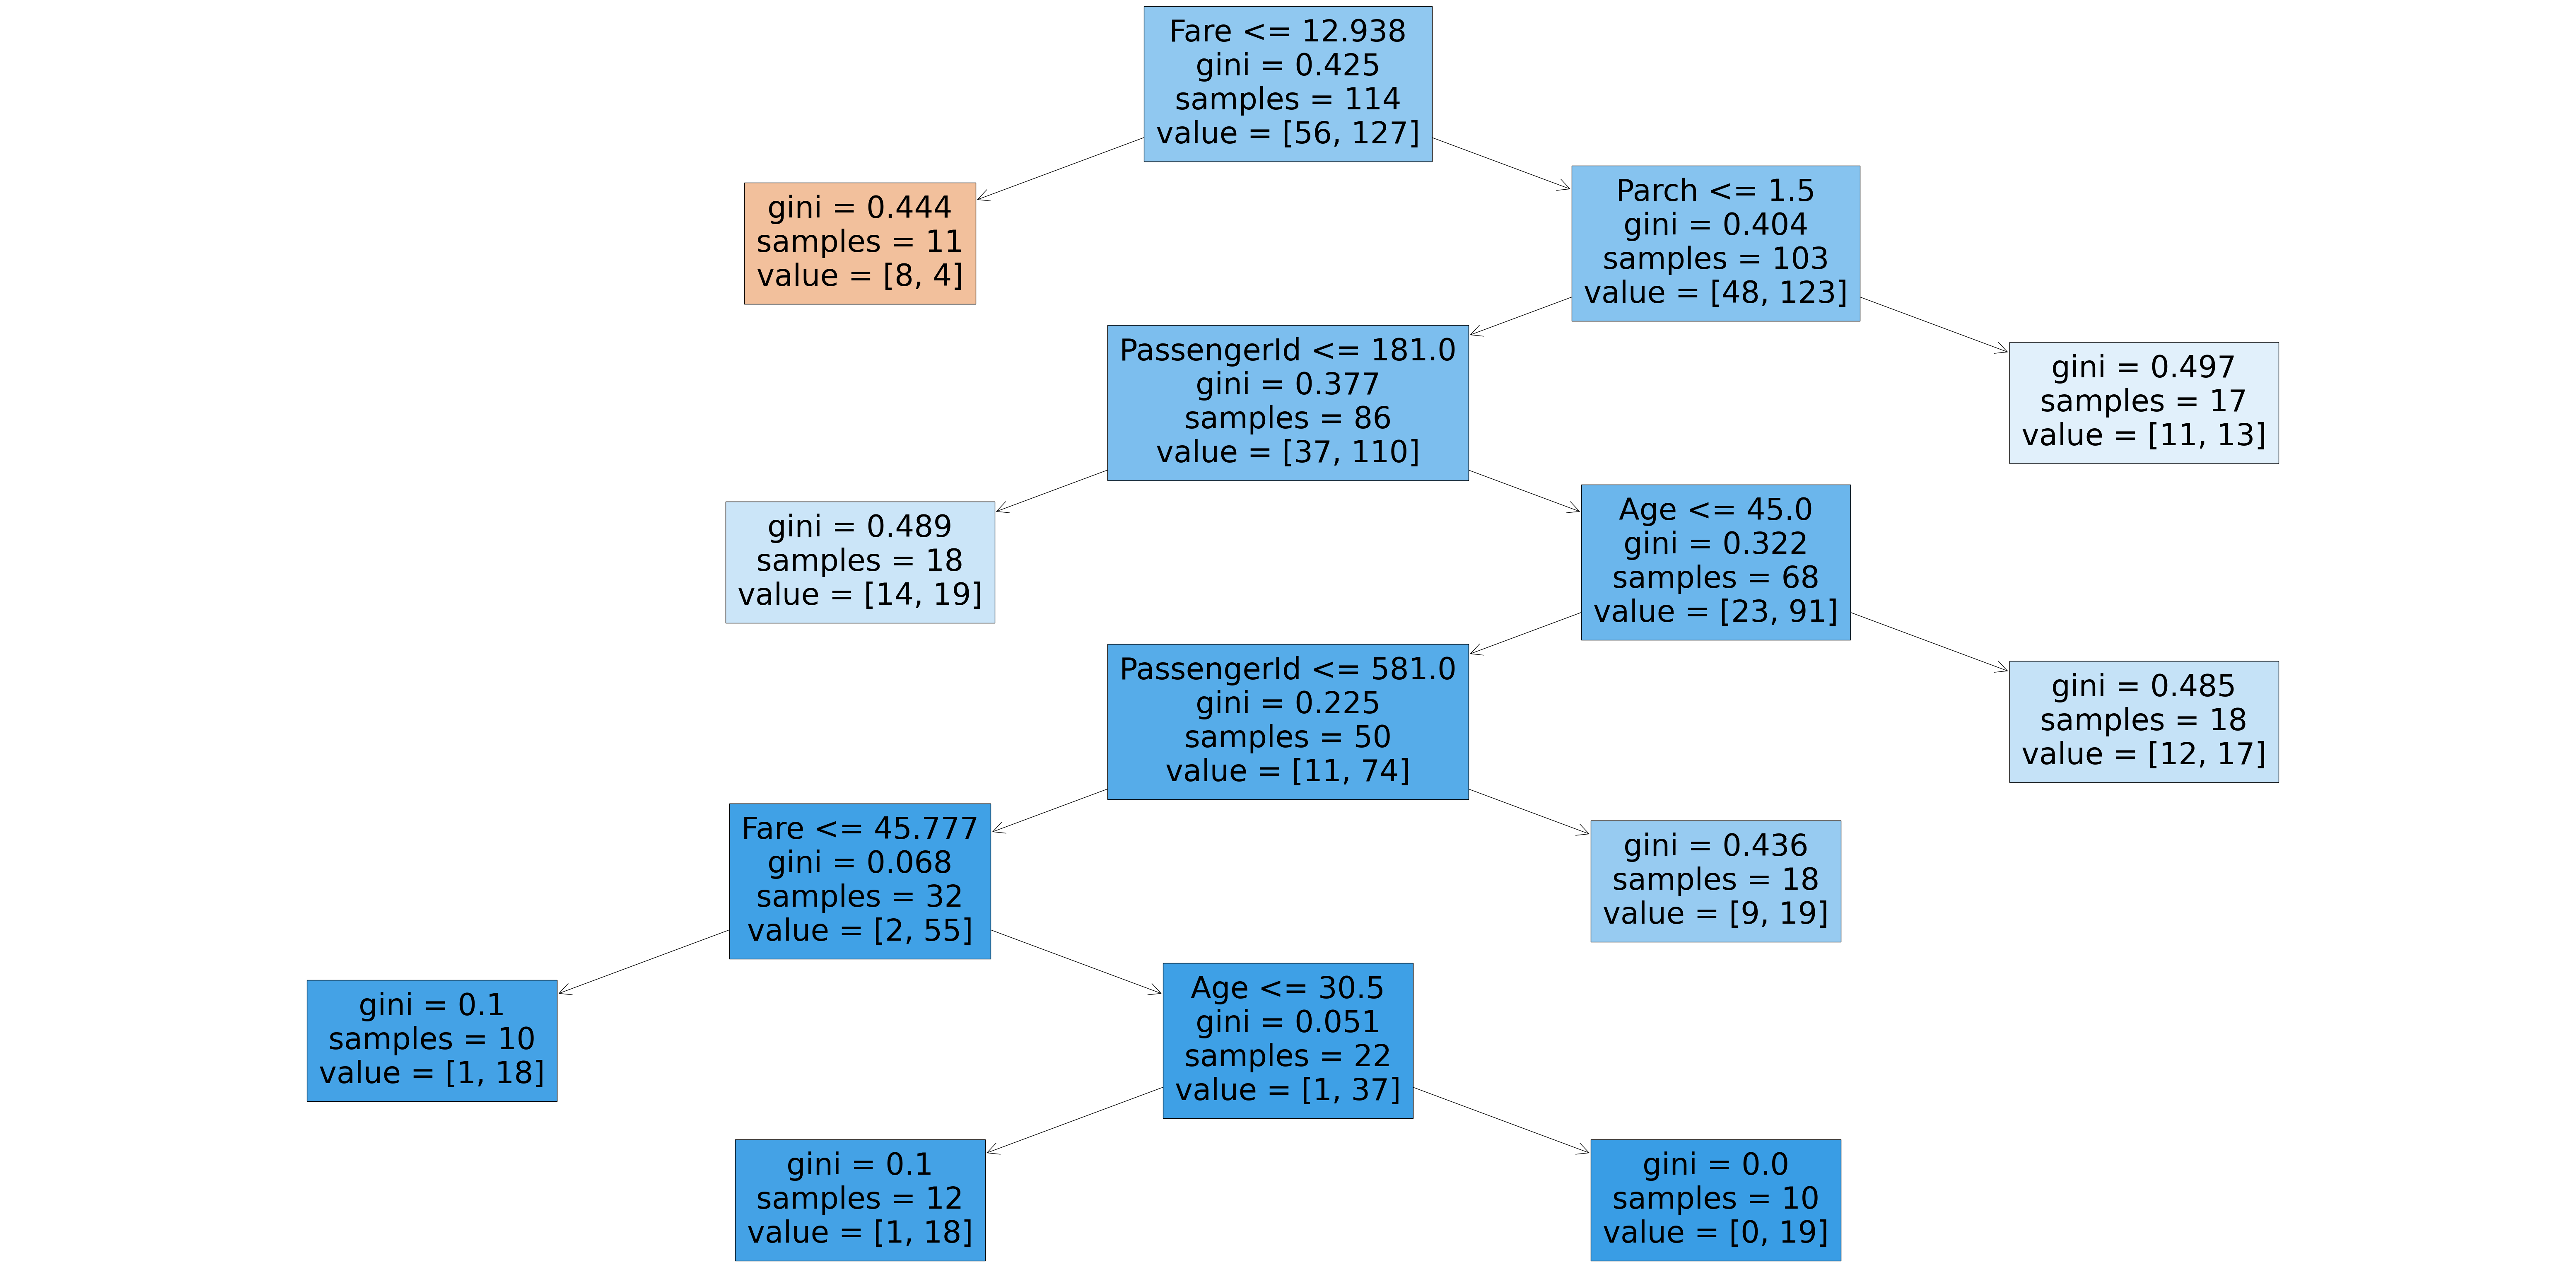

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[9], feature_names = preprocessed_train_df[x].columns.tolist(),filled=True);

In [17]:
rf_best.feature_importances_

array([0.20411388, 0.0033504 , 0.51327469, 0.02185674, 0.04134218,
       0.21606211])

In [18]:
imp_df = pd.DataFrame({
    "Varname": preprocessed_train_df[x].columns.tolist(),
    "Imp": rf_best.feature_importances_
})

imp_df.sort_values(by="Imp", ascending=False).reset_index()

,index,Varname,Imp
0,2,Age,0.513275
1,5,Fare,0.216062
2,0,PassengerId,0.204114
3,4,Parch,0.041342
4,3,SibSp,0.021857
5,1,Pclass,0.003350


## Predictions

In [19]:
preprocessed_serving_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,892,3,Kelly Mr James,male,34.5,0,0,330911,7.8292,NaN,Q,330911,NONE
1,893,3,Wilkes Mrs James Ellen Needs,female,47.0,1,0,363272,7.0000,NaN,S,363272,NONE
2,894,2,Myles Mr Thomas Francis,male,62.0,0,0,240276,9.6875,NaN,Q,240276,NONE
3,895,3,Wirz Mr Albert,male,27.0,0,0,315154,8.6625,NaN,S,315154,NONE
4,896,3,Hirvonen Mrs Alexander Helga E Lindqvist,female,22.0,1,1,3101298,12.2875,NaN,S,3101298,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Spector Mr Woolf,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,3236,A.5.
414,1306,1,Oliva y Ocana Dona Fermina,female,39.0,0,0,PC 17758,108.9000,C105,C,17758,PC
415,1307,3,Saether Mr Simon Sivertsen,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,3101262,SOTON/O.Q.
416,1308,3,Ware Mr Frederick,male,NaN,0,0,359309,8.0500,NaN,S,359309,NONE


In [21]:
serving_df=serving_df.dropna()
y_pred = grid_search.predict(serving_df.drop(columns = ['Name','Sex','Ticket','Cabin','Embarked']))

c:\Users\Mxf65s7\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [22]:
y_pred

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

In [23]:
serving_df['rf_val'] = y_pred

In [28]:
serving_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,rf_val
12,904,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S,1
14,906,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S,0
24,916,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,1
26,918,1,"Ostby, Miss. Helene Ragnhild",female,22.0,0,1,113509,61.9792,B36,C,1
28,920,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S,1


In [306]:
train_df[train_df['Survived'] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,C83,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.6500,F G73,S
92,93,0,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.1750,E31,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
102,103,0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,77.2875,D26,S
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52.0000,C110,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
